In [1]:
# CELL 1 — Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

SILVER_PATH = r"C:\Users\Lenovo\Downloads\nyc_taxi_project\silver\yellow_trips_silver.parquet"
df = pd.read_parquet(SILVER_PATH)
print(f"Loaded {len(df):,} records")

Loaded 2,883,081 records


In [2]:
# CELL 2 — Prepare features for predicting fare amount
# Use a sample of 200k rows to keep training fast
df_ml = df.sample(200000, random_state=42)

# Features (inputs) and Target (what we want to predict)
FEATURES = [
    "trip_distance_miles",
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_location_id",
    "dropoff_location_id",
    "passenger_count",
    "trip_duration_minutes"
]
TARGET = "fare_amount"

df_ml = df_ml[FEATURES + [TARGET]].dropna()

X = df_ml[FEATURES]
y = df_ml[TARGET]

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")

Training rows : 160,000
Testing rows  : 40,000


In [3]:
# CELL 3 — Train Model 1: Linear Regression (simple baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2  = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"  MAE (avg error) : ${lr_mae:.2f}")
print(f"  R2 Score        : {lr_r2:.3f}  (1.0 = perfect)")

Linear Regression Results:
  MAE (avg error) : $2.38
  R2 Score        : 0.917  (1.0 = perfect)


In [4]:
# CELL 4 — Train Model 2: Random Forest (more powerful)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"  MAE (avg error) : ${rf_mae:.2f}")
print(f"  R2 Score        : {rf_r2:.3f}  (1.0 = perfect)")

Random Forest Results:
  MAE (avg error) : $0.86
  R2 Score        : 0.964  (1.0 = perfect)


In [5]:
# CELL 5 — Compare both models
comparison = pd.DataFrame({
    "Model"    : ["Linear Regression", "Random Forest"],
    "MAE ($)"  : [round(lr_mae, 2), round(rf_mae, 2)],
    "R2 Score" : [round(lr_r2, 3),  round(rf_r2, 3)]
})
print("Model Comparison:")
display(comparison)

Model Comparison:


,Model,MAE ($),R2 Score
0,Linear Regression,2.38,0.917
1,Random Forest,0.86,0.964


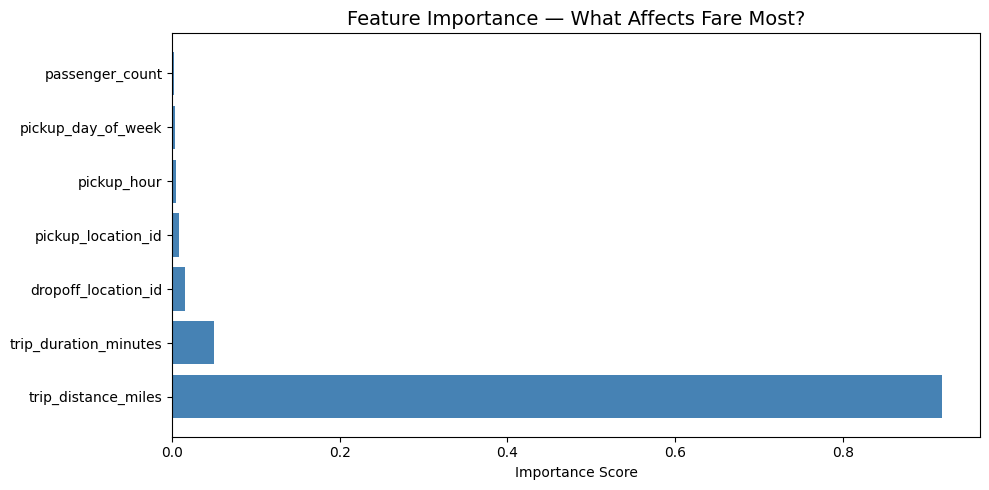

              Feature  Importance
  trip_distance_miles    0.918055
trip_duration_minutes    0.049717
  dropoff_location_id    0.015457
   pickup_location_id    0.007480
          pickup_hour    0.004446
   pickup_day_of_week    0.003074
      passenger_count    0.001771


In [6]:
# CELL 6 — Feature importance (what matters most for fare prediction)
importance = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.title("Feature Importance — What Affects Fare Most?", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print(importance.to_string(index=False))

In [7]:
# CELL 7 — Try predicting a real trip!
sample_trip = pd.DataFrame([{
    "trip_distance_miles"  : 3.5,     # 3.5 mile trip
    "pickup_hour"          : 18,      # 6 PM
    "pickup_day_of_week"   : 4,       # Friday
    "pickup_location_id"   : 161,     # Midtown
    "dropoff_location_id"  : 236,     # Upper East Side
    "passenger_count"      : 1,
    "trip_duration_minutes": 15.0
}])

predicted_fare = rf_model.predict(sample_trip)[0]
print(f"Predicted fare for your trip: ${predicted_fare:.2f}")

Predicted fare for your trip: $17.99
